In [5]:
%pip install pandas numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\deepi\AppData\Local\Programs\Mu Editor\Python\pythonw.exe -m pip install --upgrade pip' command.


c:\Users\deepi\AppData\Local\Programs\Mu Editor\Python\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\deepi\AppData\Local\Programs\Mu Editor\Python\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\deepi\AppData\Local\Programs\Mu Editor\Python\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\deepi\AppData\Local\Programs\Mu Editor\Python\lib\subprocess.py", li

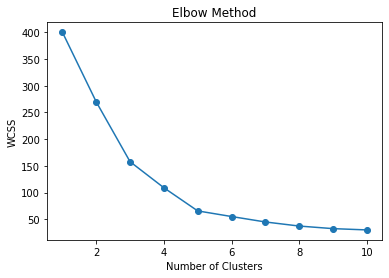

c:\Users\deepi\AppData\Local\Programs\Mu Editor\Python\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


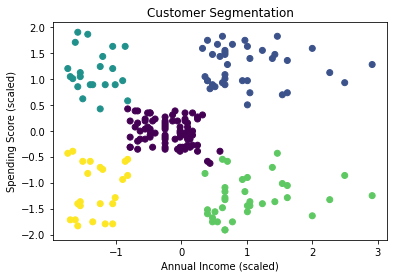

✅ Model training completed and saved as kmeans.pkl


In [ ]:
# ================================
# CUSTOMER SEGMENTATION - FULL TRAINING PIPELINE
# ================================

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pickle

# -------------------------------
# Step 1: Load Dataset
# -------------------------------
df = pd.read_csv(r"C:\Users\deepi\Music\Machine learning projects\Customer segmentation using clustering\Mall_Customers.csv")

# -------------------------------
# Step 2: Data Preprocessing
# -------------------------------

# Drop unnecessary column
df.drop("CustomerID", axis=1, inplace=True)

# Encode categorical column (Gender)
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})

# Select features
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------------
# Step 3: Elbow Method
# -------------------------------
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# -------------------------------
# Step 4: Train Final Model
# -------------------------------
optimal_k = 5  # Change based on elbow graph

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# Add cluster to dataset
df["Cluster"] = y_kmeans

# -------------------------------
# Step 5: Visualization
# -------------------------------
plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans)
plt.title("Customer Segmentation")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.show()

# -------------------------------
# Step 6: Save Model + Scaler
# -------------------------------
pickle.dump(kmeans, open("kmeans.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("✅ Model training completed and saved as kmeans.pkl")